In [ ]:
 pip install datasets

In [ ]:
!pip install -U datasets pyarrow pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 121.1 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas

In [ ]:
from datasets import load_dataset

# Example: English (US)
train_ds = load_dataset(
    "parquet",
    data_files="https://huggingface.co/datasets/AmazonScience/massive/resolve/refs%2Fconvert%2Fparquet/en-US/train/0000.parquet",
    split="train"
)

val_ds = load_dataset(
    "parquet",
    data_files="https://huggingface.co/datasets/AmazonScience/massive/resolve/refs%2Fconvert%2Fparquet/en-US/validation/0000.parquet",
    split="train"
)

test_ds = load_dataset(
    "parquet",
    data_files="https://huggingface.co/datasets/AmazonScience/massive/resolve/refs%2Fconvert%2Fparquet/en-US/test/0000.parquet",
    split="train"
)

print(train_ds)
print(train_ds[0])
print(train_ds.column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


0000.parquet:   0%|          | 0.00/676k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

0000.parquet:   0%|          | 0.00/140k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

0000.parquet:   0%|          | 0.00/191k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['id', 'locale', 'partition', 'scenario', 'intent', 'utt', 'annot_utt', 'worker_id', 'slot_method', 'judgments'],
    num_rows: 11514
})
{'id': '1', 'locale': 'en-US', 'partition': 'train', 'scenario': 16, 'intent': 48, 'utt': 'wake me up at nine am on friday', 'annot_utt': 'wake me up at [time : nine am] on [date : friday]', 'worker_id': '1', 'slot_method': {'slot': [], 'method': []}, 'judgments': {'worker_id': [], 'intent_score': [], 'slots_score': [], 'grammar_score': [], 'spelling_score': [], 'language_identification': []}}
['id', 'locale', 'partition', 'scenario', 'intent', 'utt', 'annot_utt', 'worker_id', 'slot_method', 'judgments']


Converting to a pandas dataframe

In [ ]:
import pandas as pd

train_df = train_ds.to_pandas()
val_df = val_ds.to_pandas()
test_df = test_ds.to_pandas()

print(train_df.head())

  id locale partition  scenario  intent                                  utt  \
0  1  en-US     train        16      48      wake me up at nine am on friday   
1  2  en-US     train        16      48  set an alarm for two hours from now   
2  4  en-US     train        10      46                           olly quiet   
3  5  en-US     train        10      46                                 stop   
4  6  en-US     train        10      46           olly pause for ten seconds   

                                           annot_utt worker_id  \
0  wake me up at [time : nine am] on [date : friday]         1   
1       set an alarm for [time : two hours from now]         1   
2                                         olly quiet         1   
3                                               stop         1   
4                olly pause for [time : ten seconds]         1   

                  slot_method  \
0  {'slot': [], 'method': []}   
1  {'slot': [], 'method': []}   
2  {'slot': [], 'method

EXPLORATORY DATA ANALYIS

Checking number of intents

In [ ]:
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("Number of unique intents in train:", train_df['intent'].nunique())
print("Train intent counts:")
print(train_df['intent'].value_counts().sort_index())

Train shape: (11514, 10)
Validation shape: (2033, 10)
Test shape: (2974, 10)
Number of unique intents in train: 60
Train intent counts:
intent
0     350
1     125
2     127
3     122
4     152
5      25
6     190
7      14
8      52
9     207
10    142
11    117
12    555
13    573
14    110
15     54
16    135
17    127
18     76
19    173
20    150
21    177
22    503
23    130
24     48
25     72
26    267
27    108
28     51
29     18
30    312
31     76
32    566
33    354
34     93
35     52
36    283
37      4
38     52
39     78
40    153
41     22
42    227
43    113
44    418
45    639
46    110
47    283
48    182
49    544
50    810
51    112
52     78
53    164
54    100
55     70
56    124
57    154
58    193
59    198
Name: count, dtype: int64


Basic Dataset Overview

In [ ]:
import pandas as pd

# Convert to pandas if not already done
train_df = train_ds.to_pandas()
val_df = val_ds.to_pandas()
test_df = test_ds.to_pandas()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain columns:")
print(train_df.columns.tolist())

print("\nTrain data types:")
print(train_df.dtypes)

Train shape: (11514, 10)
Validation shape: (2033, 10)
Test shape: (2974, 10)

Train columns:
['id', 'locale', 'partition', 'scenario', 'intent', 'utt', 'annot_utt', 'worker_id', 'slot_method', 'judgments']

Train data types:
id                str
locale            str
partition         str
scenario        int64
intent          int64
utt               str
annot_utt         str
worker_id         str
slot_method    object
judgments      object
dtype: object


View first 5 rows


In [ ]:
print(train_df.head())

  id locale partition  scenario  intent                                  utt  \
0  1  en-US     train        16      48      wake me up at nine am on friday   
1  2  en-US     train        16      48  set an alarm for two hours from now   
2  4  en-US     train        10      46                           olly quiet   
3  5  en-US     train        10      46                                 stop   
4  6  en-US     train        10      46           olly pause for ten seconds   

                                           annot_utt worker_id  \
0  wake me up at [time : nine am] on [date : friday]         1   
1       set an alarm for [time : two hours from now]         1   
2                                         olly quiet         1   
3                                               stop         1   
4                olly pause for [time : ten seconds]         1   

                  slot_method  \
0  {'slot': [], 'method': []}   
1  {'slot': [], 'method': []}   
2  {'slot': [], 'method

Checking for missing values

In [ ]:
print("Missing values in train:")
print(train_df.isnull().sum())

print("\nMissing values in validation:")
print(val_df.isnull().sum())

print("\nMissing values in test:")
print(test_df.isnull().sum())

Missing values in train:
id             0
locale         0
partition      0
scenario       0
intent         0
utt            0
annot_utt      0
worker_id      0
slot_method    0
judgments      0
dtype: int64

Missing values in validation:
id             0
locale         0
partition      0
scenario       0
intent         0
utt            0
annot_utt      0
worker_id      0
slot_method    0
judgments      0
dtype: int64

Missing values in test:
id             0
locale         0
partition      0
scenario       0
intent         0
utt            0
annot_utt      0
worker_id      0
slot_method    0
judgments      0
dtype: int64


Check Duplicates

In [ ]:
train_duplicates = train_df.duplicated(subset=["utt", "intent"]).sum()
val_duplicates = val_df.duplicated(subset=["utt", "intent"]).sum()
test_duplicates = test_df.duplicated(subset=["utt", "intent"]).sum()

print("Duplicate utterance-intent pairs in train:", train_duplicates)
print("Duplicate utterance-intent pairs in validation:", val_duplicates)
print("Duplicate utterance-intent pairs in test:", test_duplicates)

Duplicate utterance-intent pairs in train: 42
Duplicate utterance-intent pairs in validation: 2
Duplicate utterance-intent pairs in test: 4


Duplicates fro utterances alone

In [ ]:
train_utt_duplicates = train_df.duplicated(subset=["utt"]).sum()
print("Duplicate utterances in train only:", train_utt_duplicates)

Duplicate utterances in train only: 46


Number of unique intents

In [ ]:
print("Number of unique intents in train:", train_df["intent"].nunique())
print("Number of unique intents in validation:", val_df["intent"].nunique())
print("Number of unique intents in test:", test_df["intent"].nunique())

Number of unique intents in train: 60
Number of unique intents in validation: 59
Number of unique intents in test: 59


Map numeric intent labels to real names

In [ ]:
intent_names = train_ds.features["intent"].names

print("Number of intent names:", len(intent_names))
print("First 10 intent names:", intent_names[:10])

# Example
print("Intent 48 =", intent_names[48])
print("Intent 46 =", intent_names[46])

Number of intent names: 60
First 10 intent names: ['datetime_query', 'iot_hue_lightchange', 'transport_ticket', 'takeaway_query', 'qa_stock', 'general_greet', 'recommendation_events', 'music_dislikeness', 'iot_wemo_off', 'cooking_recipe']
Intent 48 = alarm_set
Intent 46 = audio_volume_mute


Creating a readable format

In [ ]:
train_df["intent_name"] = train_df["intent"].apply(lambda x: intent_names[x])
val_df["intent_name"] = val_df["intent"].apply(lambda x: intent_names[x])
test_df["intent_name"] = test_df["intent"].apply(lambda x: intent_names[x])

print(train_df[["utt", "intent", "intent_name"]].head())

                                   utt  intent        intent_name
0      wake me up at nine am on friday      48          alarm_set
1  set an alarm for two hours from now      48          alarm_set
2                           olly quiet      46  audio_volume_mute
3                                 stop      46  audio_volume_mute
4           olly pause for ten seconds      46  audio_volume_mute


Checking class distribution

In [ ]:
intent_counts = train_df["intent_name"].value_counts()

print(intent_counts)
print("\nLeast frequent intents:")
print(intent_counts.tail(10))

print("\nMost frequent intents:")
print(intent_counts.head(10))

intent_name
calendar_set                810
play_music                  639
weather_query               573
calendar_query              566
general_quirky              555
qa_factoid                  544
news_query                  503
email_query                 418
email_sendemail             354
datetime_query              350
calendar_remove             312
play_radio                  283
social_post                 283
qa_definition               267
transport_query             227
cooking_recipe              207
lists_query                 198
play_podcasts               193
recommendation_events       190
alarm_set                   182
lists_createoradd           177
recommendation_locations    173
lists_remove                164
music_query                 154
iot_hue_lightoff            153
qa_stock                    152
play_audiobook              150
qa_currency                 142
takeaway_order              135
alarm_query                 130
transport_ticket            

Class distribution visuals

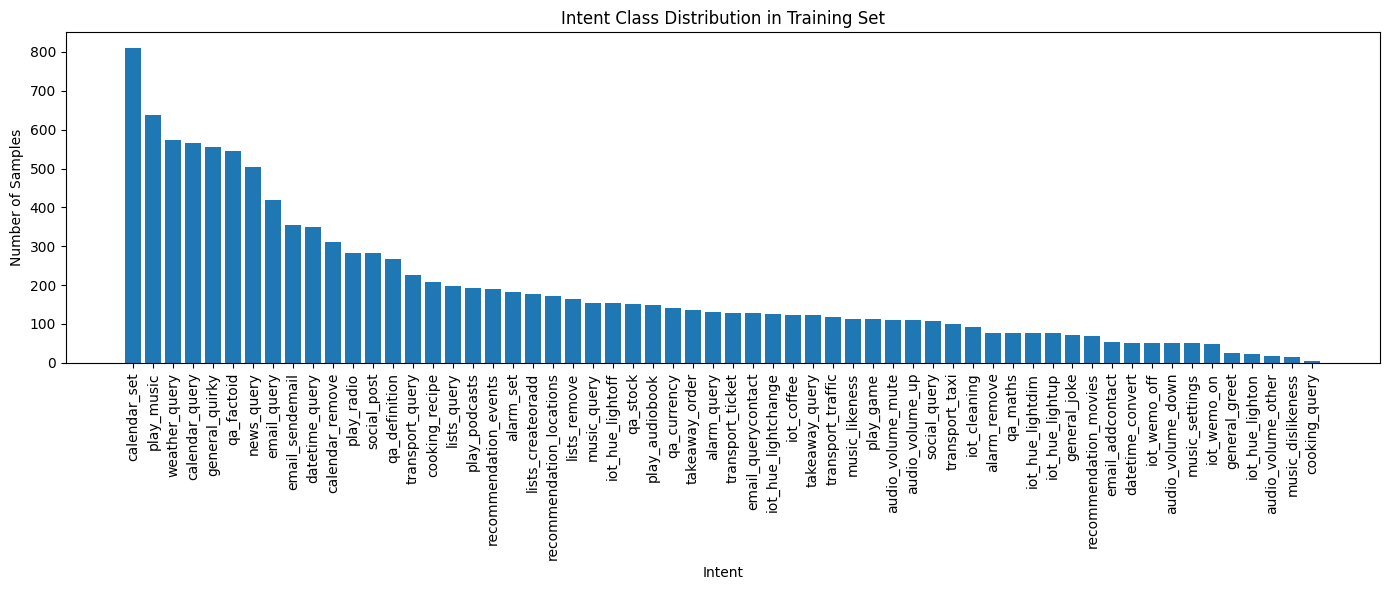

In [ ]:
import matplotlib.pyplot as plt

intent_counts_sorted = intent_counts.sort_values(ascending=False)

plt.figure(figsize=(14,6))
plt.bar(intent_counts_sorted.index, intent_counts_sorted.values)
plt.xticks(rotation=90)
plt.title("Intent Class Distribution in Training Set")
plt.xlabel("Intent")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

Check text length statistics

In [ ]:
train_df["word_count"] = train_df["utt"].apply(lambda x: len(str(x).split()))
val_df["word_count"] = val_df["utt"].apply(lambda x: len(str(x).split()))
test_df["word_count"] = test_df["utt"].apply(lambda x: len(str(x).split()))

train_df["char_count"] = train_df["utt"].apply(lambda x: len(str(x)))
val_df["char_count"] = val_df["utt"].apply(lambda x: len(str(x)))
test_df["char_count"] = test_df["utt"].apply(lambda x: len(str(x)))

Summary statistics

In [ ]:
print("Word count statistics (train):")
print(train_df["word_count"].describe())

print("\nCharacter count statistics (train):")
print(train_df["char_count"].describe())

Word count statistics (train):
count    11514.000000
mean         6.924787
std          3.284967
min          1.000000
25%          5.000000
50%          6.000000
75%          9.000000
max         35.000000
Name: word_count, dtype: float64

Character count statistics (train):
count    11514.000000
mean        35.038735
std         16.604056
min          2.000000
25%         24.000000
50%         32.000000
75%         44.000000
max        189.000000
Name: char_count, dtype: float64


Word count distribution

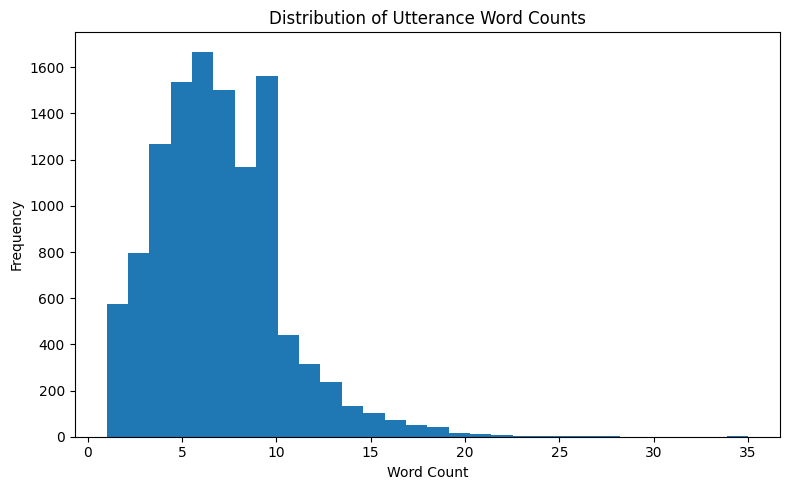

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(train_df["word_count"], bins=30)
plt.title("Distribution of Utterance Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Scenario distribution

In [ ]:
print("Unique scenarios:", train_df["scenario"].nunique())
print(train_df["scenario"].value_counts().sort_index())

Unique scenarios: 18
scenario
0      391
1      571
2     1688
3     1377
4      503
5      402
6      433
7      953
8      769
9      652
10     290
11     539
12    1183
13     211
14     257
15     332
16     390
17     573
Name: count, dtype: int64


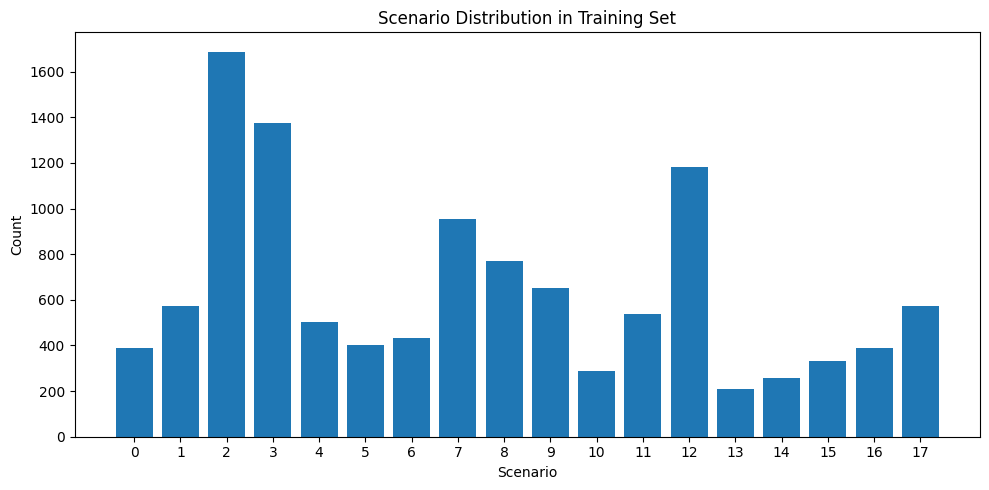

In [ ]:
scenario_counts = train_df["scenario"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(scenario_counts.index.astype(str), scenario_counts.values)
plt.title("Scenario Distribution in Training Set")
plt.xlabel("Scenario")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Summary eda

In [ ]:
print("EDA SUMMARY")
print("="*40)
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("Number of intents:", train_df["intent_name"].nunique())
print("Min samples per intent:", intent_counts.min())
print("Max samples per intent:", intent_counts.max())
print("Average samples per intent:", round(intent_counts.mean(), 2))
print("Duplicate utterance-intent pairs in train:", train_duplicates)
print("Missing utt values in train:", train_df["utt"].isnull().sum())
print("Missing intent values in train:", train_df["intent"].isnull().sum())
print("Average words per utterance:", round(train_df["word_count"].mean(), 2))
print("Median words per utterance:", round(train_df["word_count"].median(), 2))

EDA SUMMARY
Train shape: (11514, 13)
Validation shape: (2033, 13)
Test shape: (2974, 13)
Number of intents: 60
Min samples per intent: 4
Max samples per intent: 810
Average samples per intent: 191.9
Duplicate utterance-intent pairs in train: 42
Missing utt values in train: 0
Missing intent values in train: 0
Average words per utterance: 6.92
Median words per utterance: 6.0


BASELINE MODEL PREPROCESSING

create clean copies of the needed columns

In [ ]:
baseline_train = train_df[["utt", "intent"]].copy()
baseline_val = val_df[["utt", "intent"]].copy()
baseline_test = test_df[["utt", "intent"]].copy()

print(baseline_train.head())

                                   utt  intent
0      wake me up at nine am on friday      48
1  set an alarm for two hours from now      48
2                           olly quiet      46
3                                 stop      46
4           olly pause for ten seconds      46


Check for missing values

In [ ]:
print("Train missing values:")
print(baseline_train.isnull().sum())

print("\nValidation missing values:")
print(baseline_val.isnull().sum())

print("\nTest missing values:")
print(baseline_test.isnull().sum())

Train missing values:
utt       0
intent    0
dtype: int64

Validation missing values:
utt       0
intent    0
dtype: int64

Test missing values:
utt       0
intent    0
dtype: int64


Cleaning

In [ ]:
print("Train missing values:")
print(baseline_train.isnull().sum())

print("\nValidation missing values:")
print(baseline_val.isnull().sum())

print("\nTest missing values:")
print(baseline_test.isnull().sum())

Train missing values:
utt       0
intent    0
dtype: int64

Validation missing values:
utt       0
intent    0
dtype: int64

Test missing values:
utt       0
intent    0
dtype: int64


Normalizing repeated spaces

In [ ]:
baseline_train["utt"] = baseline_train["utt"].str.replace(r"\s+", " ", regex=True)
baseline_val["utt"] = baseline_val["utt"].str.replace(r"\s+", " ", regex=True)
baseline_test["utt"] = baseline_test["utt"].str.replace(r"\s+", " ", regex=True)

define features and labels

In [ ]:
X_train = baseline_train["utt"]
y_train = baseline_train["intent"]

X_val = baseline_val["utt"]
y_val = baseline_val["intent"]

X_test = baseline_test["utt"]
y_test = baseline_test["intent"]

print("Sample text:", X_train.iloc[0])
print("Sample label:", y_train.iloc[0])

Sample text: wake me up at nine am on friday
Sample label: 48


Baseline model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        max_features=5000
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

Fitting the model

In [ ]:
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

val_preds = baseline_model.predict(X_val)
test_preds = baseline_model.predict(X_test)

print("Validation Accuracy:", accuracy_score(y_val, val_preds))
print("Validation Macro F1:", f1_score(y_val, val_preds, average="macro"))
print("Validation Weighted F1:", f1_score(y_val, val_preds, average="weighted"))

print("\nTest Accuracy:", accuracy_score(y_test, test_preds))
print("Test Macro F1:", f1_score(y_test, test_preds, average="macro"))
print("Test Weighted F1:", f1_score(y_test, test_preds, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, test_preds))

Validation Accuracy: 0.8140678799803246
Validation Macro F1: 0.7998693125882437
Validation Weighted F1: 0.8144695307706543

Test Accuracy: 0.7955615332885003
Test Macro F1: 0.7518663119045997
Test Weighted F1: 0.7962693942853172

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        88
           1       0.81      0.83      0.82        36
           2       0.94      0.91      0.93        35
           3       0.74      0.74      0.74        35
           4       0.82      0.88      0.85        26
           5       0.07      1.00      0.12         1
           6       0.59      0.74      0.66        43
           7       0.50      0.75      0.60         4
           8       0.71      0.83      0.77        18
           9       0.86      0.78      0.82        72
          10       0.88      0.92      0.90        39
          11       0.71      1.00      0.83        15
          12       0.61      0.43      0.50 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The TF-IDF and Logistic Regression baseline achieved a test accuracy of 79.56%, with a weighted F1-score of 79.63% and a macro F1-score of 75.19%. The lower macro F1-score compared to the weighted F1-score indicates that the model performed better on frequent intents than on rare ones, which is consistent with the class imbalance observed during exploratory data analysis.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, test_preds, zero_division=0))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82        88
           1       0.81      0.83      0.82        36
           2       0.94      0.91      0.93        35
           3       0.74      0.74      0.74        35
           4       0.82      0.88      0.85        26
           5       0.07      1.00      0.12         1
           6       0.59      0.74      0.66        43
           7       0.50      0.75      0.60         4
           8       0.71      0.83      0.77        18
           9       0.86      0.78      0.82        72
          10       0.88      0.92      0.90        39
          11       0.71      1.00      0.83        15
          12       0.61      0.43      0.50       169
          13       0.87      0.91      0.89       156
          14       0.65      0.85      0.73        13
          15       0.45      0.75      0.56        12
          16       0.68      0.77      0.72        22
          17       0.58    

Distilbert Model

In [ ]:
!pip install -U transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.8/526.8 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 47.8 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: datasets
    Found existing installation: datasets 4.8.2
    Uninstalling datasets-4.8.2:
      Successfully uninstalled datasets-4.8.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


Building Distilbert Ready Datasets

In [ ]:
distilbert_train = train_df[["utt", "intent"]].copy()
distilbert_val = val_df[["utt", "intent"]].copy()
distilbert_test = test_df[["utt", "intent"]].copy()

distilbert_train = distilbert_train.dropna(subset=["utt", "intent"])
distilbert_val = distilbert_val.dropna(subset=["utt", "intent"])
distilbert_test = distilbert_test.dropna(subset=["utt", "intent"])

distilbert_train["utt"] = distilbert_train["utt"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
distilbert_val["utt"] = distilbert_val["utt"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
distilbert_test["utt"] = distilbert_test["utt"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

print(distilbert_train.head())
print(distilbert_train.shape, distilbert_val.shape, distilbert_test.shape)

                                   utt  intent
0      wake me up at nine am on friday      48
1  set an alarm for two hours from now      48
2                           olly quiet      46
3                                 stop      46
4           olly pause for ten seconds      46
(11514, 2) (2033, 2) (2974, 2)


Load tokenizer and model label mappings

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_checkpoint = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

intent_names = train_ds.features["intent"].names
id2label = {i: name for i, name in enumerate(intent_names)}
label2id = {name: i for i, name in enumerate(intent_names)}

num_labels = len(intent_names)

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

print("Number of labels:", num_labels)
print("Example label mapping:", id2label[48])

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Number of labels: 60
Example label mapping: alarm_set


In [ ]:
from datasets import Dataset

train_hf = Dataset.from_pandas(distilbert_train.reset_index(drop=True))
val_hf = Dataset.from_pandas(distilbert_val.reset_index(drop=True))
test_hf = Dataset.from_pandas(distilbert_test.reset_index(drop=True))

print(train_hf)
print(train_hf[0])

Dataset({
    features: ['utt', 'intent'],
    num_rows: 11514
})
{'utt': 'wake me up at nine am on friday', 'intent': 48}


Tokenizing Text

In [ ]:
def tokenize_function(examples):
    return tokenizer(examples["utt"], truncation=True)

train_hf = train_hf.rename_column("intent", "labels")
val_hf = val_hf.rename_column("intent", "labels")
test_hf = test_hf.rename_column("intent", "labels")

tokenized_train = train_hf.map(tokenize_function, batched=True)
tokenized_val = val_hf.map(tokenize_function, batched=True)
tokenized_test = test_hf.map(tokenize_function, batched=True)

print(tokenized_train[0])

Map:   0%|          | 0/11514 [00:00<?, ? examples/s]

Map:   0%|          | 0/2033 [00:00<?, ? examples/s]

Map:   0%|          | 0/2974 [00:00<?, ? examples/s]

{'utt': 'wake me up at nine am on friday', 'labels': 48, 'input_ids': [101, 5256, 2033, 2039, 2012, 3157, 2572, 2006, 5958, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


Define Metrics

In [ ]:
pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [ ]:
import evaluate
import numpy as np
from sklearn.metrics import f1_score

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )["accuracy"]

    macro_f1 = f1_score(labels, predictions, average="macro")
    weighted_f1 = f1_score(labels, predictions, average="weighted")

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }

Creating a Trainer

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert_massive_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="weighted_f1",
    greater_is_better=True,
    report_to="none"
)

In [ ]:
from transformers import DataCollatorWithPadding, Trainer, EarlyStoppingCallback

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.669314,0.818365,0.825873,0.661665,0.808816
2,0.622322,0.533448,0.869651,0.795387,0.866229
3,0.338389,0.476665,0.878013,0.822966,0.876105
4,0.202828,0.492221,0.880472,0.839183,0.878013
5,0.126742,0.492479,0.888834,0.863986,0.888510


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=5040, training_loss=0.4413101340097094, metrics={'train_runtime': 8977.3983, 'train_samples_per_second': 12.826, 'train_steps_per_second': 0.802, 'total_flos': 364788532584000.0, 'train_loss': 0.4413101340097094, 'epoch': 7.0})

In [ ]:
eval_results = trainer.evaluate()
print(eval_results)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.4924585521221161, 'eval_accuracy': 0.8888342351205115, 'eval_macro_f1': 0.863986214788773, 'eval_weighted_f1': 0.8885104501847123, 'eval_runtime': 68.3052, 'eval_samples_per_second': 29.763, 'eval_steps_per_second': 1.874, 'epoch': 7.0}


In [ ]:
test_results = trainer.predict(tokenized_test)
print(test_results.metrics)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'test_loss': 0.5222560167312622, 'test_accuracy': 0.8802958977807667, 'test_macro_f1': 0.8512151838747276, 'test_weighted_f1': 0.8804143064432055, 'test_runtime': 109.3478, 'test_samples_per_second': 27.198, 'test_steps_per_second': 1.701}


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

model_path = "/content/drive/MyDrive/best_distilbert_massive_model"  # adjust if needed

# Check if the path exists
if os.path.exists(model_path):
    print("Contents:")
    for file in os.listdir(model_path):
        print(file)
else:
    print("Folder not found. Check the name and path.")

Contents:
config.json
model.safetensors
tokenizer_config.json
tokenizer.json
training_args.bin


Loading the model

In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Check number of labels (should be 60 for MASSIVE en-US)
print("Number of labels:", model.config.num_labels)

# Show a few label mappings
print("First 5 intent mappings:")
for i in range(5):
    print(f"{i}: {model.config.id2label[i]}")

# Test with a sample utterance
test_text = "play some music"
inputs = tokenizer(test_text, return_tensors="pt", truncation=True)
outputs = model(**inputs)
pred = torch.argmax(outputs.logits, dim=-1).item()
print(f"Predicted intent id: {pred}")
print(f"Intent name: {model.config.id2label[pred]}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Number of labels: 60
First 5 intent mappings:
0: datetime_query
1: iot_hue_lightchange
2: transport_ticket
3: takeaway_query
4: qa_stock
Predicted intent id: 45
Intent name: play_music


METRICS RESULTS

Mount Drive and load the test dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')

from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load test split
test_ds = load_dataset(
    "parquet",
    data_files="https://huggingface.co/datasets/AmazonScience/massive/resolve/refs%2Fconvert%2Fparquet/en-US/test/0000.parquet",
    split="train"
)
test_df = test_ds.to_pandas()

# Clean utterances (same as in training)
test_df["utt"] = test_df["utt"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

# Ground truth labels
y_true = test_df["intent"].values

# Load intent names (if needed for plotting)
intent_names = test_ds.features["intent"].names

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


0000.parquet:   0%|          | 0.00/191k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Load the fine‑tuned DistilBERT model from Drive

In [6]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_path = "/content/drive/MyDrive/best_distilbert_massive_model"   # adjust if needed

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


 Predict on test set with DistilBERT

In [7]:
def tokenize_batch(texts):
    return tokenizer(texts, truncation=True, padding=True, return_tensors="pt")

batch_size = 64
predictions = []

for i in range(0, len(test_df), batch_size):
    batch_texts = test_df["utt"].iloc[i:i+batch_size].tolist()
    inputs = tokenize_batch(batch_texts).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        predictions.extend(preds)

y_pred_distilbert = np.array(predictions)

Computing Overall metrics


In [8]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

acc = accuracy_score(y_true, y_pred_distilbert)
macro_f1 = f1_score(y_true, y_pred_distilbert, average="macro")
weighted_f1 = f1_score(y_true, y_pred_distilbert, average="weighted")

print("DistilBERT Test Results:")
print(f"Accuracy:   {acc:.4f}")
print(f"Macro F1:   {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

DistilBERT Test Results:
Accuracy:   0.8803
Macro F1:   0.8512
Weighted F1: 0.8804


In [17]:
cm = confusion_matrix(y_true, y_pred_distilbert, labels=range(60))

misclass = []
for i in range(60):
    for j in range(60):
        if i != j and cm[i, j] > 0:
            misclass.append((intent_names[i], intent_names[j], cm[i, j]))
misclass.sort(key=lambda x: x[2], reverse=True)

print("Top 10 most confused intent pairs:")
for true_intent, pred_intent, count in misclass[:10]:
    print(f"{true_intent} → {pred_intent}: {count} samples")

Top 10 most confused intent pairs:
general_quirky → qa_factoid: 21 samples
qa_factoid → general_quirky: 10 samples
general_quirky → calendar_query: 8 samples
calendar_query → calendar_set: 7 samples
play_radio → play_music: 7 samples
calendar_set → calendar_query: 7 samples
general_quirky → news_query: 5 samples
qa_definition → general_quirky: 5 samples
datetime_convert → datetime_query: 5 samples
iot_hue_lightchange → iot_hue_lightup: 4 samples


BASELINE MODEL

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Load training data again
train_ds = load_dataset(
    "parquet",
    data_files="https://huggingface.co/datasets/AmazonScience/massive/resolve/refs%2Fconvert%2Fparquet/en-US/train/0000.parquet",
    split="train"
)
train_df = train_ds.to_pandas()
train_df["utt"] = train_df["utt"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
X_train = train_df["utt"]
y_train = train_df["intent"]

# Build baseline pipeline
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, ngram_range=(1,2), max_features=5000)),
    ("clf", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
])
baseline_model.fit(X_train, y_train)

0000.parquet:   0%|          | 0.00/676k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

Predicting on Set

In [20]:
y_pred_baseline = baseline_model.predict(test_df["utt"])

Baseline Metrics

In [21]:
acc_base = accuracy_score(y_true, y_pred_baseline)
macro_f1_base = f1_score(y_true, y_pred_baseline, average="macro")
weighted_f1_base = f1_score(y_true, y_pred_baseline, average="weighted")

print("Baseline Test Results:")
print(f"Accuracy:   {acc_base:.4f}")
print(f"Macro F1:   {macro_f1_base:.4f}")
print(f"Weighted F1: {weighted_f1_base:.4f}")

Baseline Test Results:
Accuracy:   0.7956
Macro F1:   0.7519
Weighted F1: 0.7963


Domain mapping function

In [27]:
from datasets import load_dataset
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Load test data (or use existing y_true, y_pred_* from earlier)
# If you already have y_true, y_pred_distilbert, y_pred_baseline, you can skip the loading.
test_ds = load_dataset(
    "parquet",
    data_files="https://huggingface.co/datasets/AmazonScience/massive/resolve/refs%2Fconvert%2Fparquet/en-US/test/0000.parquet",
    split="train"
)
intent_names = test_ds.features['intent'].names
y_true = test_ds['intent']  # integer labels (0..59)

# If you haven't computed predictions yet, load models and compute now.
# For DistilBERT:
# model_path = "/content/drive/MyDrive/best_distilbert_massive_model"
# tokenizer, model = ...
# y_pred_distilbert = ...
# For baseline:
# y_pred_baseline = ... (from your earlier run)

# Domain mapping
def get_domain_map(intent_names):
    mapping = {}
    for name in intent_names:
        if '_' in name:
            domain = name.split('_')[0]
        else:
            domain = name
        mapping[name] = domain
    return mapping

domain_map = get_domain_map(intent_names)
domains = sorted(set(domain_map.values()))
print(f"Found {len(domains)} domains: {domains}")

# True domain labels (same for both models)
true_domains = [domain_map[intent_names[i]] for i in y_true]

Found 18 domains: ['alarm', 'audio', 'calendar', 'cooking', 'datetime', 'email', 'general', 'iot', 'lists', 'music', 'news', 'play', 'qa', 'recommendation', 'social', 'takeaway', 'transport', 'weather']


Confusion Metrics for baseline

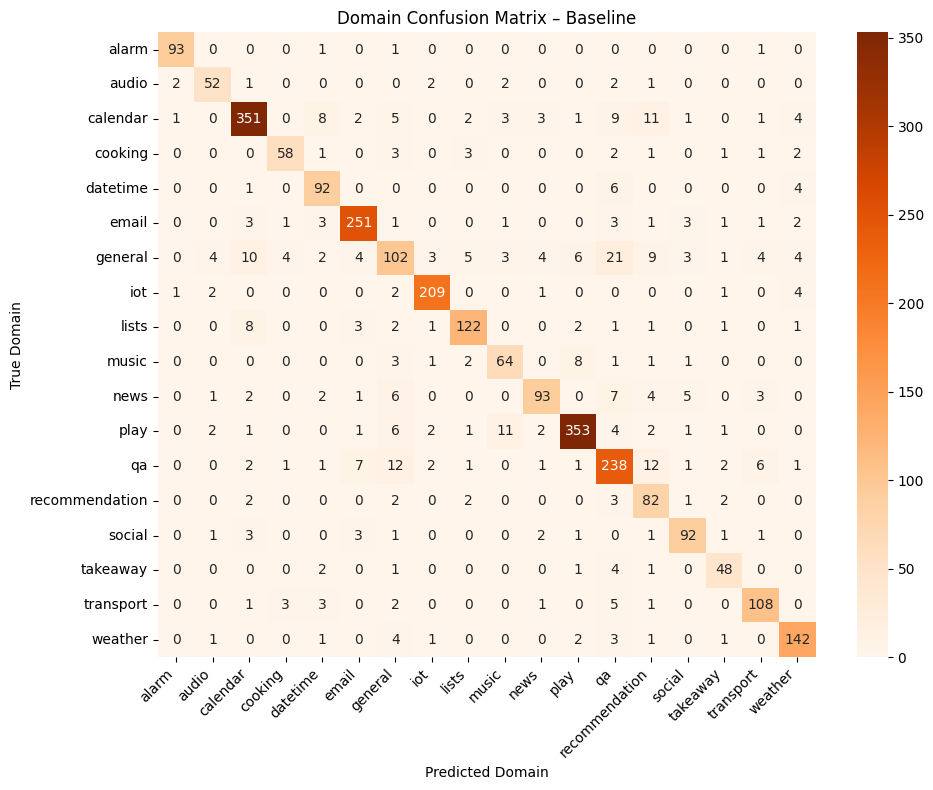

Top 5 domain misclassifications (Baseline):
general → qa: 21
qa → general: 12
qa → recommendation: 12
calendar → recommendation: 11
play → music: 11


In [28]:
# For Baseline
pred_domains_baseline = [domain_map[intent_names[i]] for i in y_pred_baseline]

cm_domain_baseline = confusion_matrix(true_domains, pred_domains_baseline, labels=domains)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_domain_baseline, annot=True, fmt='d', cmap='Oranges',
            xticklabels=domains, yticklabels=domains)
plt.title('Domain Confusion Matrix – Baseline')
plt.xlabel('Predicted Domain')
plt.ylabel('True Domain')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

misclass_base = []
for i, d_true in enumerate(domains):
    for j, d_pred in enumerate(domains):
        if i != j and cm_domain_baseline[i, j] > 0:
            misclass_base.append((d_true, d_pred, cm_domain_baseline[i, j]))
misclass_base.sort(key=lambda x: x[2], reverse=True)
print("Top 5 domain misclassifications (Baseline):")
for d_true, d_pred, cnt in misclass_base[:5]:
    print(f"{d_true} → {d_pred}: {cnt}")

Confusion matrix for distilbert

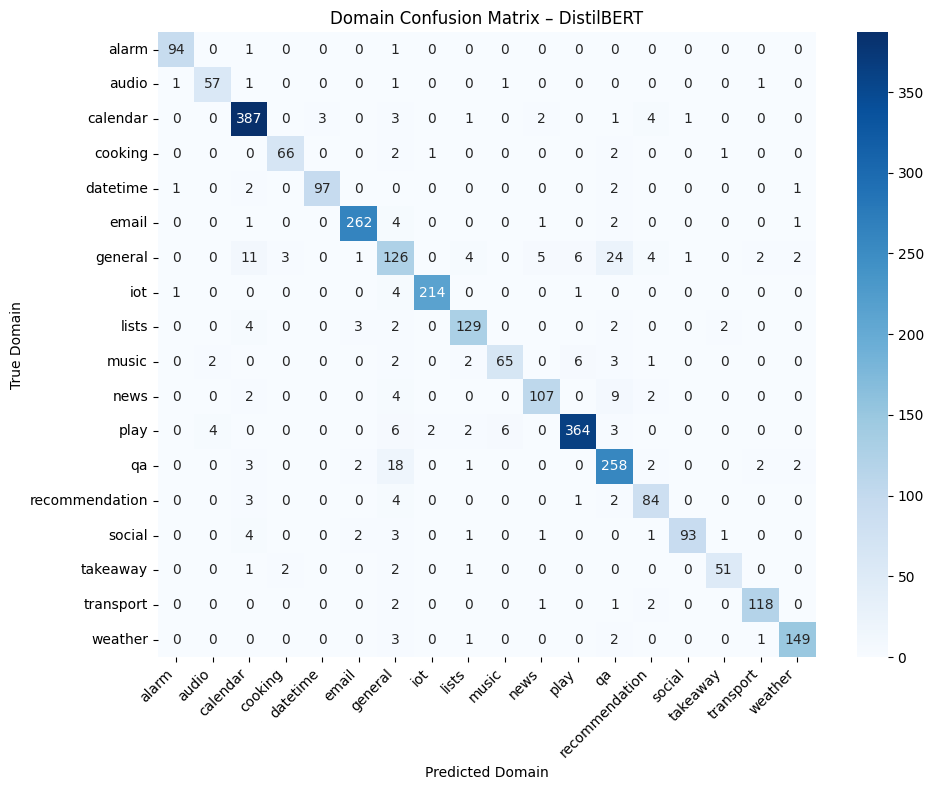

Top 5 domain misclassifications (DistilBERT):
general → qa: 24
qa → general: 18
general → calendar: 11
news → qa: 9
general → play: 6


In [29]:
# For DistilBERT
pred_domains_distilbert = [domain_map[intent_names[i]] for i in y_pred_distilbert]

cm_domain_distilbert = confusion_matrix(true_domains, pred_domains_distilbert, labels=domains)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_domain_distilbert, annot=True, fmt='d', cmap='Blues',
            xticklabels=domains, yticklabels=domains)
plt.title('Domain Confusion Matrix – DistilBERT')
plt.xlabel('Predicted Domain')
plt.ylabel('True Domain')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Optional top misclassifications
misclass = []
for i, d_true in enumerate(domains):
    for j, d_pred in enumerate(domains):
        if i != j and cm_domain_distilbert[i, j] > 0:
            misclass.append((d_true, d_pred, cm_domain_distilbert[i, j]))
misclass.sort(key=lambda x: x[2], reverse=True)
print("Top 5 domain misclassifications (DistilBERT):")
for d_true, d_pred, cnt in misclass[:5]:
    print(f"{d_true} → {d_pred}: {cnt}")

Comparison Table

In [23]:
results = pd.DataFrame({
    "Model": ["Baseline (TF‑IDF + LR)", "DistilBERT (fine‑tuned)"],
    "Accuracy": [acc_base, acc],
    "Macro F1": [macro_f1_base, macro_f1],
    "Weighted F1": [weighted_f1_base, weighted_f1]
})
print(results)

                     Model  Accuracy  Macro F1  Weighted F1
0   Baseline (TF‑IDF + LR)  0.795562  0.751866     0.796269
1  DistilBERT (fine‑tuned)  0.880296  0.851215     0.880414


Testing the Distilbert model

In [30]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Path to your saved model (adjust if needed)
model_path = "/content/drive/MyDrive/best_distilbert_massive_model"

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def predict_intent(text):
    """Return predicted intent name and confidence for a single utterance."""
    inputs = tokenizer(text, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
        pred_id = np.argmax(probs)
        intent_name = model.config.id2label[pred_id]
        confidence = probs[pred_id]
    return intent_name, confidence

# Sample utterances for a sanity check
test_utterances = [
    "what's the weather like today",
    "set an alarm for 7 am",
    "play some music",
    "what's the capital of France",
    "remind me to call mom at 5",
    "turn on the living room lights",
    "how do I get to the airport",
    "tell me a joke"
]

print("Sanity Test Results (DistilBERT)")
print("="*60)
for text in test_utterances:
    intent, conf = predict_intent(text)
    print(f"Utterance: {text}")
    print(f"Predicted Intent: {intent} (confidence: {conf:.3f})")
    print("-"*60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Sanity Test Results (DistilBERT)
Utterance: what's the weather like today
Predicted Intent: weather_query (confidence: 0.999)
------------------------------------------------------------
Utterance: set an alarm for 7 am
Predicted Intent: alarm_set (confidence: 0.995)
------------------------------------------------------------
Utterance: play some music
Predicted Intent: play_music (confidence: 0.985)
------------------------------------------------------------
Utterance: what's the capital of France
Predicted Intent: qa_factoid (confidence: 0.998)
------------------------------------------------------------
Utterance: remind me to call mom at 5
Predicted Intent: calendar_set (confidence: 0.999)
------------------------------------------------------------
Utterance: turn on the living room lights
Predicted Intent: iot_hue_lighton (confidence: 0.637)
------------------------------------------------------------
Utterance: how do I get to the airport
Predicted Intent: transport_query (con